In [1]:
## Creating tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper 

In [2]:
# Tool-1
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=5, doc_content_chars_max=200)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke('Redemption all you need')

'Published: 2020-05-14\nTitle: Street Marketing: How Proximity and Context drive Coupon Redemption\nAuthors: Sarah Spiekermann, Matthias Rothensee, Michael Klafft\nSummary: Purpose: In 2009, US coupons se'

In [4]:
# Tool-2
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [7]:
## Tavily Search tool 
# Tool-3
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [8]:
tavily.invoke('Provide me the recent ai news')

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': 'Physical AI\n\nMarch 31, 2026\n\n#### Enterprise\n\n### IDC: How EMEA CIOs can jumpstart AI rollouts\n\nGovernance, Regulation & Policy\n\nApril 29, 2026\n\n### Google warns malicious web pages are poisoning AI agents\n\nGovernance, Regulation & Policy\n\nApril 27, 2026\n\n### Why AI agents need interaction infrastructure\n\nGovernance, Regulation & Policy\n\nApril 24, 2026\n\n#### Industries\n\n### AI in law firms entering its closing summaries\n\nLegal Industry AI\n\nApril 22, 2026\n\n### Trustpilot partners with AI companies as traditional search declines\n\nRetail & Logistics AI\n\nMarch 17, 2026\n\n### Agentic AI in finance speeds up operational automation\n\nFinance AI\n\nMarch 10, 2026\n\n#### Deep Learning\n\n### IBM Research unveils breakthrough analog AI chip for efficient deep learning\n\nAI Market Trends\n\nAugust 11, 2023 

In [9]:
## combine all the tools in the list
tools = [arxiv, wiki, tavily]

In [12]:
## Initialize the llm model
from langchain_groq import ChatGroq

llm = ChatGroq(model='llama-3.1-8b-instant')

In [13]:
llm.invoke("What is AI")

AIMessage(content='AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of making computers or machines think and act like humans, and is designed to perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experiences, and interactions, and improve their performance over time.\n2. **Problem-solving**: AI systems can analyze complex data, identify patterns, and make decisions based on that analysis.\n3. **Reasoning**: AI systems can draw conclusions from data and make logical decisions.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak A

In [14]:
# llm will have the info about the tools
llm_with_tools = llm.bind_tools(tools=tools) 

In [15]:
# Excute the call
llm_with_tools.invoke("What is the recent news of ai?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sftncgsqq', 'function': {'arguments': '{"query":"Recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 461, 'total_tokens': 481, 'completion_time': 0.036853067, 'completion_tokens_details': None, 'prompt_time': 0.026064913, 'prompt_tokens_details': None, 'queue_time': 0.051264486, 'total_time': 0.06291798}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de386-21e4-7653-a012-1f98868a280d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Recent AI news'}, 'id': 'sftncgsqq', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 461, 'output_tokens': 20, 'total_tokens': 481})

## Workflow (LangGraph)

In [22]:
## State Schema
from typing_extensions import TypedDict 
from typing import Annotated ## Labelling
from langchain_core.messages import AnyMessage, HumanMessage ## AnyMessage : Human message or AI message
from langgraph.graph.message import add_messages ## Reducers in langGraph

In [17]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

    """ Reducers in LangGraph -> 
        - list[Anymessages] : it will append all the messages 
          whether it is ai or human with the help of the add_messages reducers.
        - add_messages reducer: It don't override the messages ; it 'append' the new message into messages
        - if we dont use the 'add_message' function then it will override the messages by adding list[AnyMessage]
          that appeares. 
    """

In [18]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition # for, when should we call the tool_node

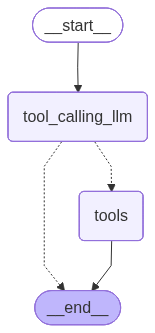

In [21]:
## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
# Run
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (w06yvpc56)
 Call ID: w06yvpc56
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The do


In [24]:
messages = graph.invoke({"messages": "Hi my name is Nick"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Nick
================================== Ai Message ==================================

I'm happy to chat with you, Nick. Is there something specific you'd like to talk about or ask about?


### ReAct Architecture

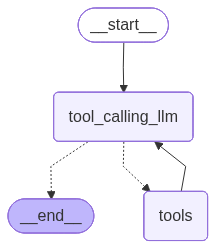

In [ ]:
##  ReAct Architecture

## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") # ***Going back to tool_calling_llm

# No need to add edge to 'End' it will go automatically//

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
messages = graph.invoke({"messages": "What is the recent AI news and please tell me about the recent research paper on quantum computing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and please tell me about the recent research paper on quantum computing?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (52j55v5a8)
 Call ID: 52j55v5a8
  Args:
    query: recent AI news
  arxiv (fzns7mv40)
 Call ID: fzns7mv40
  Args:
    query: quantum computing recent research paper
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "Governance, Regulation & Policy\n\nApril 29, 2026\n\n# IDC: How EMEA CIOs can jumpstart AI rollouts\n\nWorld of Work\n\nApril 29, 2026\n\n# GPT-5.5 is OpenAI’s most capable agentic AI model yet\n\nIBM logo as, to regulate software delivery costs and SDLC governance, 